# Simple Univariate Linear Regression Example with Linear Model / Fit

- Generate data:

$$𝑦 = 15 𝑥 + 5 + noise $$

- Then try to learn:

$$ \hat{𝑦} = 𝑤_0 + 𝑤_1 𝑥$$

- Using gradient descent to minimize squared error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize Random Number Generator

The `np.random.default_rng()`constructor initializes a random number generator in modern NumPy (version 1.17 and later) by instantiating a `Generator` object that provides access to a wide range of probability distributions and random sampling methods.

Unlike the legacy `np.random.seed()`, which sets a global state that can be unintentionally modified by other libraries, `np.random.default_rng()` creates an independent instance. This isolation ensures better reproducibility and modularity.

You can pass a seed (e.g., `np.random.default_rng(42)`) to ensure the sequence of random numbers is the same every time you run your code.

In [2]:
np.random.default_rng(42)

Generator(PCG64) at 0x1B5E3004C80

In [3]:
# generate 10 random numbers from a normal (Gaussian) distribution with mean as 0 and standard devation as 0.4
np.random.normal(0, 0.4, 10)

array([ 0.21832498, -0.4558544 , -0.27725193,  0.31015574,  0.48022417,
        0.38540412, -0.2087253 , -0.19276692,  0.05527992,  0.15818768])

`np.random.normal(0, 0.4, 10)` samples from a normal distribution, which is:
- Unbounded → it can theoretically produce values from −∞ to +∞.
- So there is no guaranteed minimum or maximum.

Even though it's unbounded, most values fall in predictable ranges:
- 68% within ±0.4
- 95% within ±0.8
- 99.7% within ±1.2

## Data Generation

In [4]:
m = 51
x = np.linspace(0, 1, m)
y = 15*x + 5 + np.random.normal(0, 0.4, len(x))
y

array([ 5.51054333,  5.21119909,  5.83503256,  5.73206588,  6.0235441 ,
        6.54614862,  6.66687342,  7.54409413,  6.77113799,  8.26261779,
        8.35427228,  8.8780966 ,  8.77017599,  8.53931302,  9.46924365,
        9.91090899,  9.30264585, 10.14013246, 10.79554721, 10.82931707,
       10.77839935, 11.65954068, 12.30950918, 12.00696729, 12.04427155,
       12.57856775, 12.5588377 , 13.2226079 , 13.50941731, 14.36556284,
       13.55772719, 13.87556802, 14.69949185, 15.12401482, 14.83948133,
       15.50273078, 16.10252793, 16.0692265 , 16.1663345 , 16.80852148,
       17.11905607, 17.26396508, 17.6686125 , 17.44341759, 18.16593252,
       18.58306938, 19.19238252, 19.7921936 , 19.84765755, 19.4601681 ,
       20.04727391])

## Visualize the generated data

Text(0.5, 1.0, 'Scatter plot of Generated data')

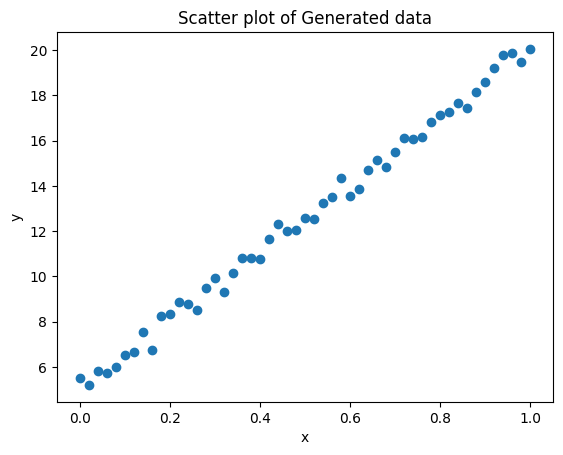

In [5]:
#plt.scatter(x, y, marker='s')
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of Generated data")

# Linear Regression

## Linear Model / Fit / Hypothesis Function

Predicted output, $\hat{y}$ is:

$$
h(x) = \hat{y} = w_0 + w_1x
$$

## Finding Linear Regression Coefficients using Gradient Descent

- We have $m$ data points $(x^{(i)}, y^{(i)}) \hspace{1cm} i = 1, 2, \cdots, m$.
- Guess $w_0$ and $w_1$.
- For any guess of $w$, we have the corresponding predicted output
$$\hat{y}^{(i)} = w_0 + w_1 x^{(i)}$$

- Calculate the cost, $C(w_0, w_1)$.
- Improve coefficients / weights by using:

$$ w_0^{iter} = w_0^{iter-1} + \delta{w_0} = w_0^{iter-1} - \eta \frac{\partial C}{\partial w_0}$$

$$ w_1^{iter} = w_1^{iter-1} + \delta{w_1} = w_1^{iter-1} - \eta \frac{\partial C}{\partial w_1}$$

- Stop when the stopping criterion is met.

## Cost Function : MSE Cost Function

$(x^{(i)}, y^{(i)})$ : $i^{th}$ "example" of (input, output) set

$m$ : Number of examples or data points

$$C(\hat{y}) = \frac{1}{2m}\sum_{i=1}^m(y^{(i)}-\hat{y}^{(i)})^2$$
$$C(w_0, w_1) = \frac{1}{2m}\sum_{i=1}^m(y^{(i)}-w_0-w_1x^{(i)})^2$$

## Gradients of the Cost Function

$$\frac{\partial C}{\partial w_0} = -\frac{1}{m} \sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)}) = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - w_0 - w_1 x^{(i)})$$

$$\frac{\partial C}{\partial w_1} = -\frac{1}{m} \sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)}) x^{(i)} = -\frac{1}{m}\sum_{i=1}^{m}(y^{(i)} - w_0 - w_1 x^{(i)})x^{(i)}$$    

## Gradient Descent Algorithm

1. Decide $\eta$ and $\epsilon$ and stopping criterion.
2. Make initial guess for the weights / co-efficients $w_0$ and $w_1$.
3. Calculate:

$$w_0^{(k+1)} = w_{0}^{(k)} - \frac{\eta}{m} \sum_{i=0}^{m}(y^{(i)} - \hat{y}^{(i)})$$

$$w_1^{(k+1)} = w_{1}^{(k)} - \frac{\eta}{m} \sum_{i=0}^{m}(y^{(i)} - \hat{y}^{(i)}) x^{(i)}$$

4. Check the stopping criterion:
   1. If condition is satified, then stop.
   2. If not satisfied, go to Step 3. 

## Stopping Criterion

The stopping criteria that we will use is 

$$error < \epsilon$$

Where $error$ could be:
$$error = |w_0^{iter} - w_0^{iter-1}|$$
$$error = |w_1^{iter} - w_1^{iter-1}|$$

or

$$error = |C^{iter} - C^{iter-1}|$$

## Set hyper parameters

In [6]:
eta = 0.1       # learning rate
eps = 1.e-4     # Stopping tolerance

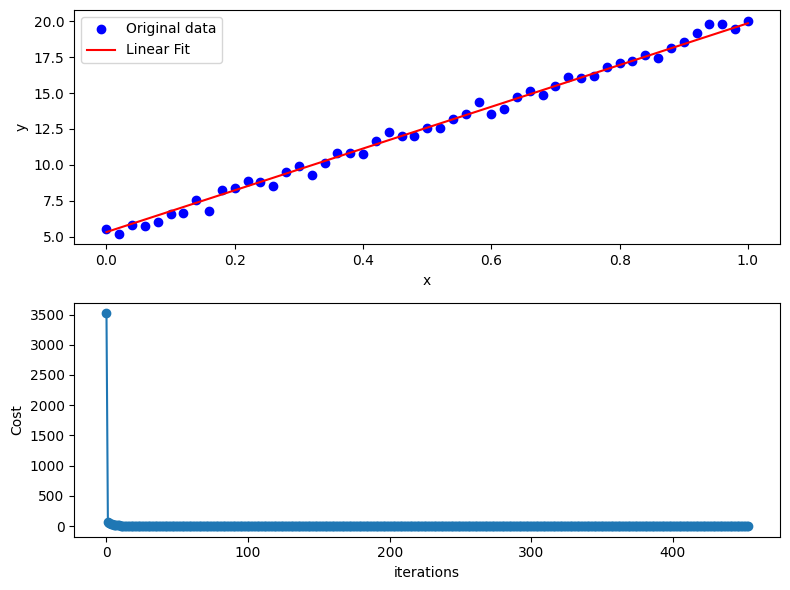

In [7]:
eta = 0.1

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*(np.sum(y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0


while error > eps:

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [8]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")
print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 0.1
Number of iterations = 453
w0 = 5.318230468368328
w1 = 14.548380330310223
Cost = 0.06000744223272601


## Stopping criteria using co-efficients / weights

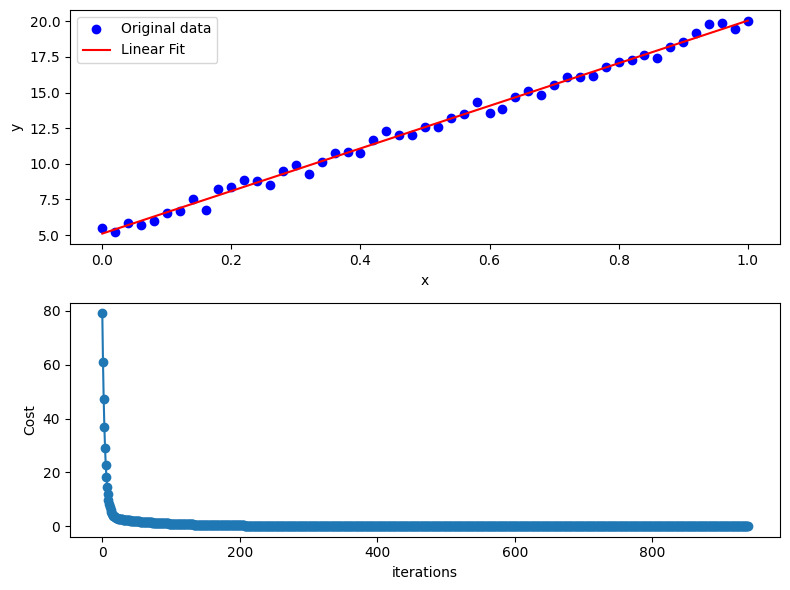

In [9]:
eta = 0.1       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [10]:
#Results
print(f"Learning Rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

Learning Rate = 0.1
Number of iterations = 939
w0 = 5.108629412860185
w1 = 14.938937934113781
Cost = 0.05279744479777167


## Faster learning

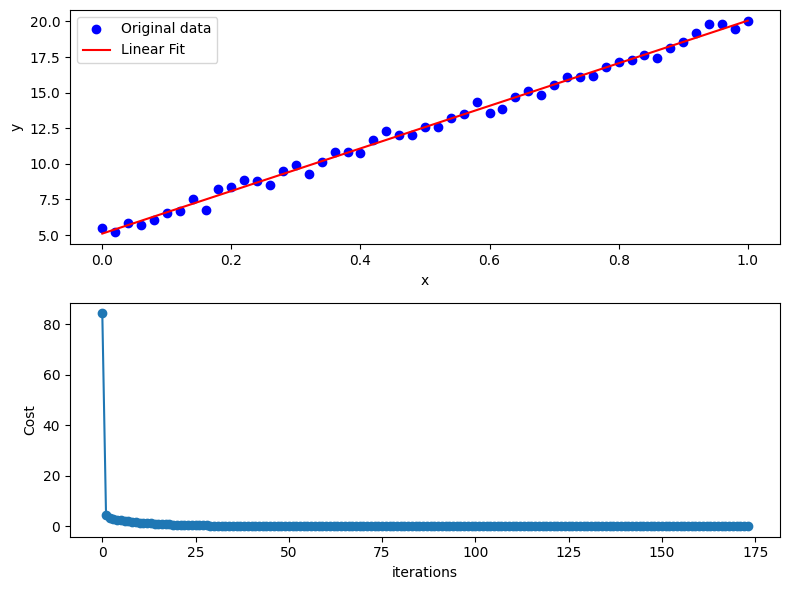

In [11]:
eta = 0.7       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [12]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 0.7
Number of iterations = 173
w0 = 5.101887878577577
w1 = 14.95149969087112
Cost = 0.05278838502391007


## Diverging Solution

C:\Users\adeet\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\adeet\AppData\Local\Temp\ipykernel_17504\4003446002.py:30: RuntimeWarning: overflow encountered in square
  cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
C:\Users\adeet\AppData\Local\Temp\ipykernel_17504\4003446002.py:20: RuntimeWarning: invalid value encountered in multiply
  nabla_w1 = -np.sum((y - yhat) * x) / m
C:\Users\adeet\AppData\Local\Temp\ipykernel_17504\4003446002.py:25: RuntimeWarning: invalid value encountered in scalar add
  w0 = w0 + dw0


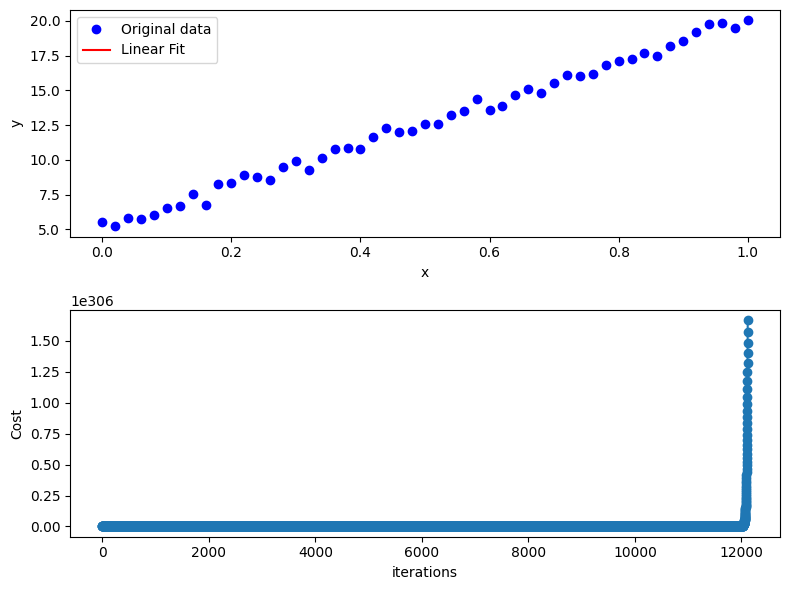

In [13]:
eta = 1.6       # learning rate

# Initialize weights
w0 = np.random.rand()
w1 = np.random.rand()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

iter = 0

error_w0 = 1
error_w1 = 1

while error_w0 > eps or error_w1 > eps:
    
    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error_w0 = abs(dw0)
    error_w1 = abs(dw1)

    yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [14]:
# Results
print(f"learning rate = {eta}")
print(f"Number of iterations = {iter}")

print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"Cost = {C[-1]}")

learning rate = 1.6
Number of iterations = 24327
w0 = nan
w1 = nan
Cost = nan
